In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Ensure project root is importable when notebook is opened from notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository root: {repo_root}")

from diffsim.data.flumy_generator import (
    FlumyGenerator,
    FACIES_NAMES,
    LITHO_NAMES,
    map_channelasso_to_litho,
    normalize_lithofacies,
    denormalize_lithofacies,
    LITHO_NORMALIZED,
    FACIES_OVERBANK,
    FACIES_CHANNEL,
    FACIES_LEVEE,
    FACIES_CRAVASSE,
    FACIES_COAL,
    FACIES_OTHERS,
)
from diffsim.data.seismic import generate_rms_from_facies_3d, DEFAULT_ROCK_PROPERTIES

# ── LITHO_FLUMY_AV (final 3-class target) colour palette ─────────────────────
LITHO_COLORS = {
    0: '#3E3E3E',  # Shale
    1: '#E6B422',  # Sand
    2: '#8FBBD9',  # Silt
}
CMAP3 = mcolors.ListedColormap([LITHO_COLORS[i] for i in range(3)])
NORM3 = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=CMAP3.N)

LITHO_PATCHES = [
    mpatches.Patch(color=LITHO_COLORS[k], label=f"{k}: {LITHO_NAMES[k]}")
    for k in range(3)
]

# Optional display palette for CHANNELASSO_AV (intermediate 6-class)
FACIES6_COLORS = {
    0: '#8B6914',
    1: '#FFD700',
    2: '#90EE90',
    3: '#FFA500',
    4: '#2F2F2F',
    5: '#BC8F8F',
}
CMAP6 = mcolors.ListedColormap([FACIES6_COLORS[i] for i in range(6)])
NORM6 = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, 6.5, 1.0), ncolors=CMAP6.N)

FACIES_DIR = Path("/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies")
RMS_DIR = Path("/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms")
EXAMPLE = "ng50_isbx80_seed6.npy"

print("Imports complete.")

Repository root: /home/tharitt/working/DiffSim


/mnt/sda_data/tharitt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports complete.


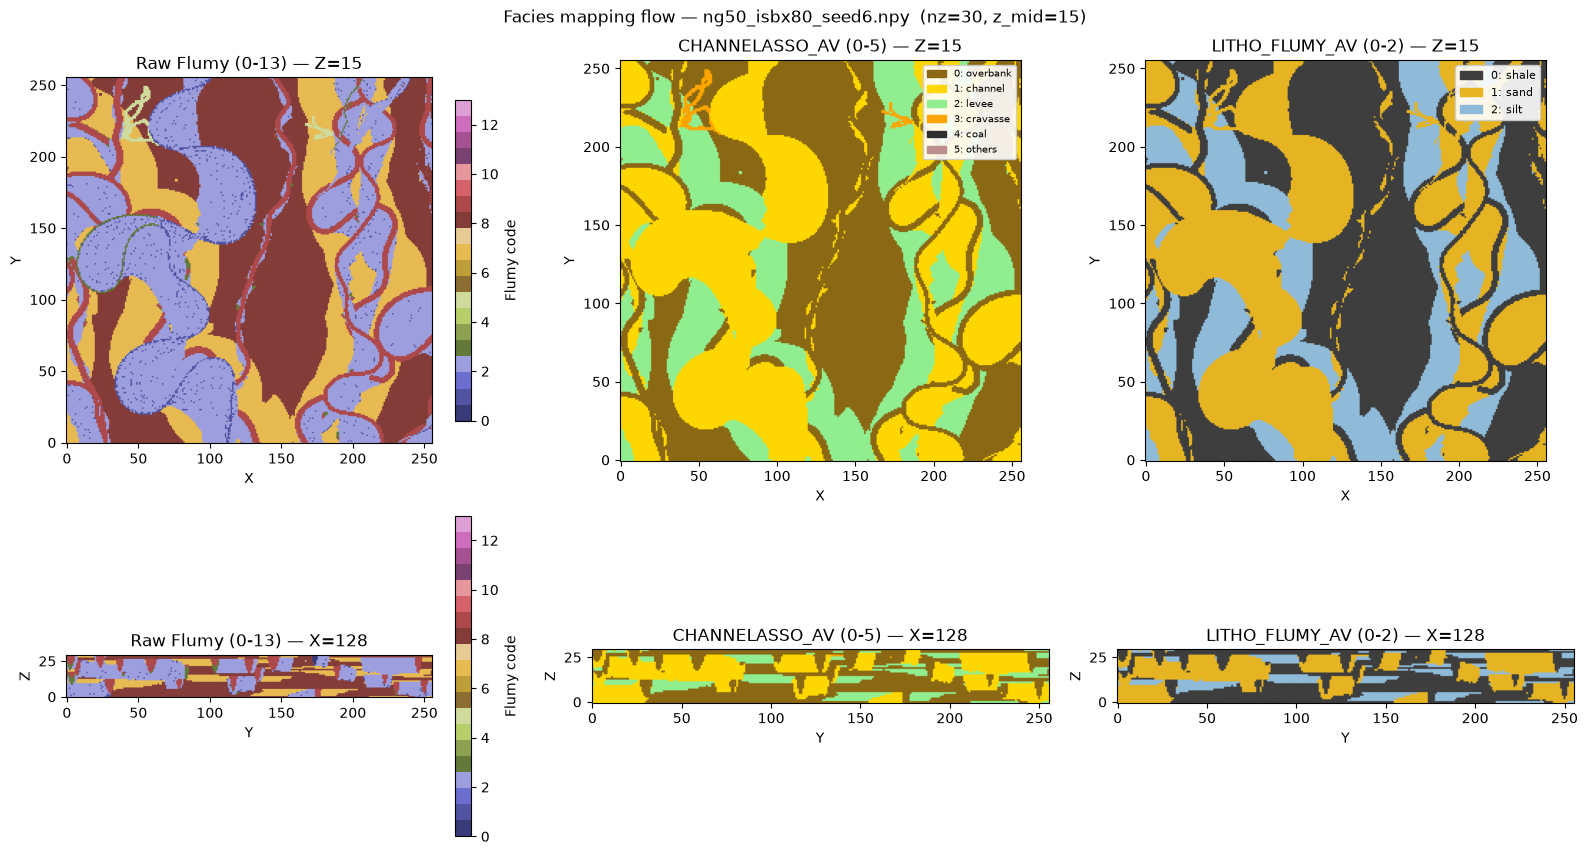

LITHO_FLUMY_AV proportions:
  0 shale:    930678  (47.3%)
  1 sand :    695042  (35.4%)
  2 silt :    340360  (17.3%)


In [2]:
# ── Raw Flumy (0-13) -> CHANNELASSO_AV (0-5) -> LITHO_FLUMY_AV (0-2) ───────
facies_raw = np.load(FACIES_DIR / EXAMPLE)
facies_6 = FlumyGenerator.reclassify_facies(facies_raw)
litho_3 = map_channelasso_to_litho(facies_6)

nx, ny, nz = facies_raw.shape
z_mid = nz // 2

legend6 = [
    mpatches.Patch(color=FACIES6_COLORS[k], label=f"{k}: {FACIES_NAMES[k]}")
    for k in range(6)
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Facies mapping flow — {EXAMPLE}  (nz={nz}, z_mid={z_mid})", fontsize=12)

for row, label in enumerate([f"Z={z_mid}", f"X={nx//2}"]):
    if row == 0:
        raw_sl = facies_raw[:, :, z_mid]
        ch6_sl = facies_6[:, :, z_mid]
        litho_sl = litho_3[:, :, z_mid]
        xl, yl = "X", "Y"
    else:
        raw_sl = facies_raw[nx // 2, :, :].T
        ch6_sl = facies_6[nx // 2, :, :].T
        litho_sl = litho_3[nx // 2, :, :].T
        xl, yl = "Y", "Z"

    im_raw = axes[row, 0].imshow(raw_sl, origin="lower", cmap="tab20b", vmin=0, vmax=13)
    axes[row, 0].set_title(f"Raw Flumy (0-13) — {label}")
    axes[row, 0].set_xlabel(xl)
    axes[row, 0].set_ylabel(yl)
    fig.colorbar(im_raw, ax=axes[row, 0], shrink=0.8, label="Flumy code")

    axes[row, 1].imshow(ch6_sl, origin="lower", cmap=CMAP6, norm=NORM6)
    axes[row, 1].set_title(f"CHANNELASSO_AV (0-5) — {label}")
    axes[row, 1].set_xlabel(xl)
    axes[row, 1].set_ylabel(yl)

    axes[row, 2].imshow(litho_sl, origin="lower", cmap=CMAP3, norm=NORM3)
    axes[row, 2].set_title(f"LITHO_FLUMY_AV (0-2) — {label}")
    axes[row, 2].set_xlabel(xl)
    axes[row, 2].set_ylabel(yl)

axes[0, 1].legend(handles=legend6, loc="upper right", fontsize=7, framealpha=0.9)
axes[0, 2].legend(handles=LITHO_PATCHES, loc="upper right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print final 3-class proportions used by training labels
total = litho_3.size
print("LITHO_FLUMY_AV proportions:")
for k, name in LITHO_NAMES.items():
    n = (litho_3 == k).sum()
    print(f"  {k} {name:5s}: {n:9d}  ({100*n/total:.1f}%)")

facies_6   shape: (256, 256, 30)
litho_3    shape: (256, 256, 30)
rms_block  shape: (256, 256, 29)  (nz-1 due to reflectivity)


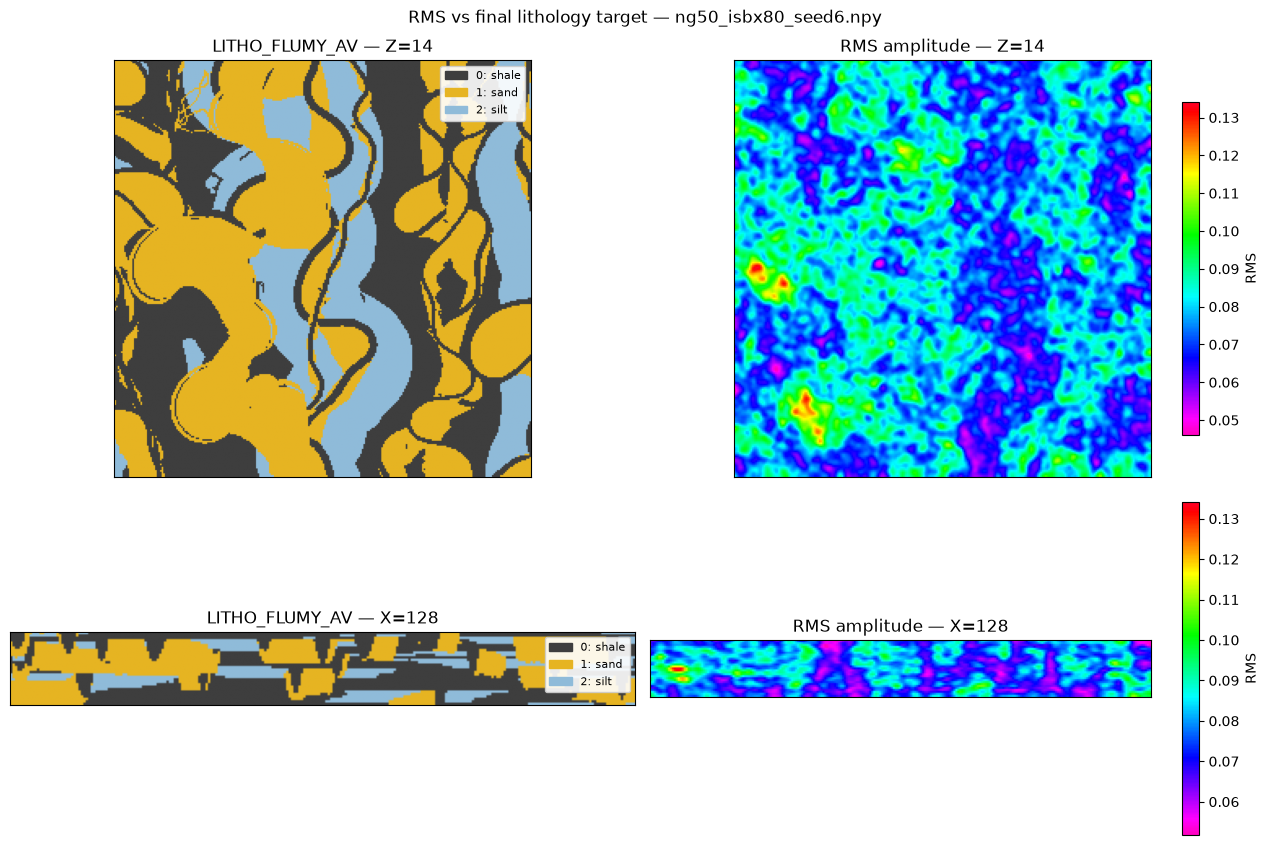

3-class normalize->denormalize roundtrip: True
Normalized codes: {0: -1.0, 1: 0.0, 2: 1.0}


In [3]:
# ── Generate RMS from CHANNELASSO_AV, display with final LITHO labels ─────────
rng = np.random.default_rng(42)
rms_block = generate_rms_from_facies_3d(
    facies_6,
    rock_properties=DEFAULT_ROCK_PROPERTIES,
    rms_window_half=1,
    noise_level=0.3,
    smooth_sigma=None,  # auto-compute from Fresnel zone
    rng=rng,
)

print(f"facies_6   shape: {facies_6.shape}")
print(f"litho_3    shape: {litho_3.shape}")
print(f"rms_block  shape: {rms_block.shape}  (nz-1 due to reflectivity)")

nx, ny, nz_rms = rms_block.shape
z_mid = nz_rms // 2

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"RMS vs final lithology target — {EXAMPLE}", fontsize=12)

for row, (plan_label, litho_sl, rms_sl) in enumerate([
    (f"Z={z_mid}", litho_3[:, :, z_mid], rms_block[:, :, z_mid]),
    (f"X={nx//2}", litho_3[nx//2, :, :].T, rms_block[nx//2, :, :].T),
]):
    axes[row, 0].imshow(litho_sl, origin="lower", cmap=CMAP3, norm=NORM3)
    axes[row, 0].set_title(f"LITHO_FLUMY_AV — {plan_label}")
    axes[row, 0].legend(handles=LITHO_PATCHES, loc="upper right", fontsize=8, framealpha=0.9)

    im = axes[row, 1].imshow(rms_sl, origin="lower", cmap="gist_rainbow_r")
    axes[row, 1].set_title(f"RMS amplitude — {plan_label}")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8, label="RMS")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Quick sanity check for the 3-class normalization used by training/inference
demo_norm = normalize_lithofacies(litho_3[:, :, z_mid])
demo_back = denormalize_lithofacies(demo_norm)
print("3-class normalize->denormalize roundtrip:", bool(np.array_equal(demo_back, litho_3[:, :, z_mid])))
print("Normalized codes:", LITHO_NORMALIZED)

Pre-computed RMS shape: (256, 256, 29)


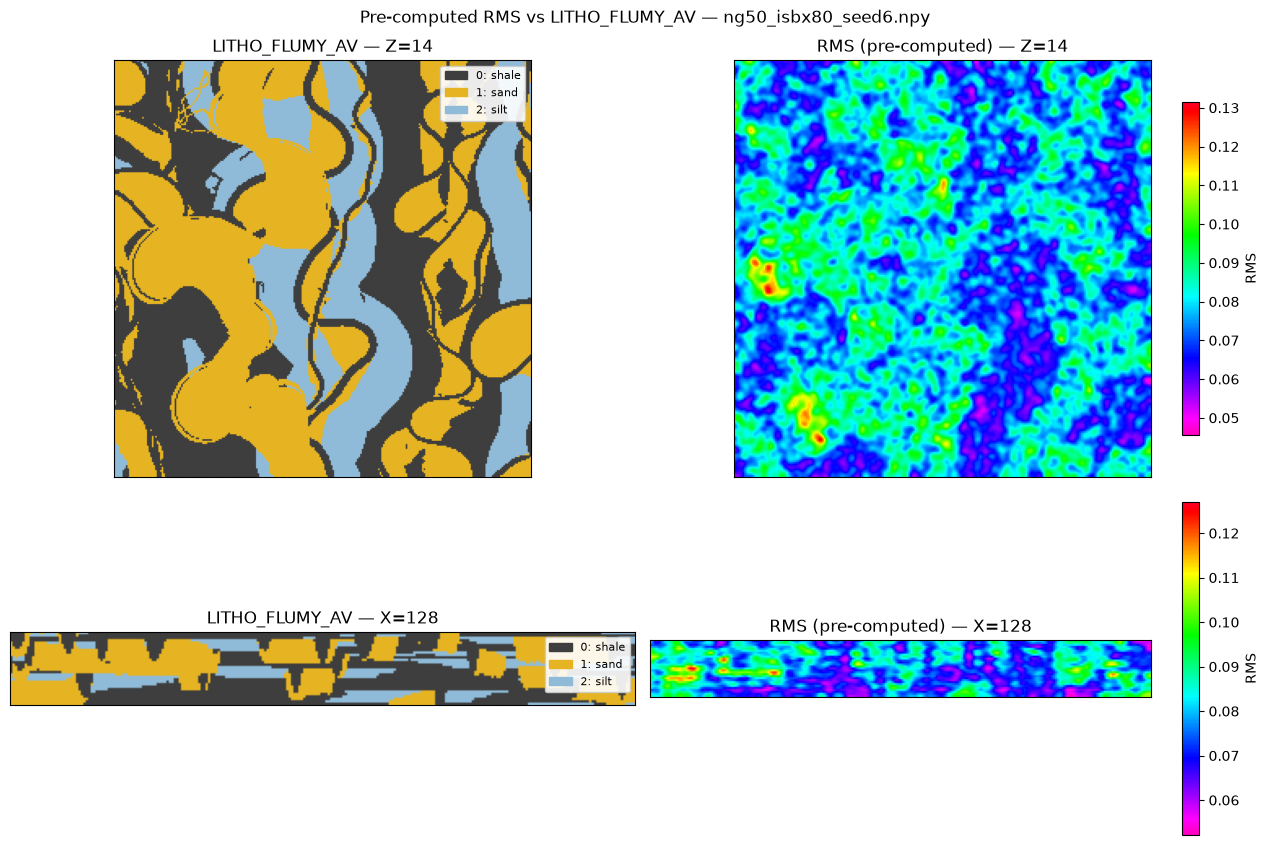

In [4]:
# ── Load pre-computed RMS cube and compare with final 3-class labels ──────────
rms_precomp = np.load(RMS_DIR / EXAMPLE)

print(f"Pre-computed RMS shape: {rms_precomp.shape}")

nx, ny, nz_rms = rms_precomp.shape
z_mid = nz_rms // 2

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Pre-computed RMS vs LITHO_FLUMY_AV — {EXAMPLE}", fontsize=12)

for row, (plan_label, litho_sl, rms_sl) in enumerate([
    (f"Z={z_mid}", litho_3[:, :, z_mid], rms_precomp[:, :, z_mid]),
    (f"X={nx//2}", litho_3[nx//2, :, :].T, rms_precomp[nx//2, :, :].T),
]):
    axes[row, 0].imshow(litho_sl, origin="lower", cmap=CMAP3, norm=NORM3)
    axes[row, 0].set_title(f"LITHO_FLUMY_AV — {plan_label}")
    axes[row, 0].legend(handles=LITHO_PATCHES, loc="upper right", fontsize=8, framealpha=0.9)

    im = axes[row, 1].imshow(rms_sl, origin="lower", cmap="gist_rainbow_r")
    axes[row, 1].set_title(f"RMS (pre-computed) — {plan_label}")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8, label="RMS")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()